# Regression Analysis: Trust vs GDP, Education, Unemployment

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import itertools


In [9]:
df = pd.read_csv("/Users/srisuphachawla/Regression_Analysis_project/Regression_Analysis_project/df_final.csv")
df

,Country,Trust,GDP,Education,Unemployment
0,Andorra,30.130722,1.970207,12.029040,2.712500
1,Argentina,18.204707,0.676644,18.081460,8.687500
2,Armenia,10.870762,4.362500,13.977807,17.287500
3,Australia,37.224962,2.300994,21.696950,5.390750
4,Brazil,4.805490,0.251022,15.417804,11.712500
5,Cabo Verde,8.357502,2.811847,12.148168,10.725000
6,Canada,45.684374,1.809385,15.951103,6.802000
7,Chile,14.935067,2.151564,16.539878,7.761000
8,Colombia,16.913874,2.887173,14.590004,11.366625
9,Costa Rica,9.860702,3.157677,15.128070,12.266875


           Trust        GDP  Education  Unemployment
count  49.000000  49.000000  49.000000     49.000000
mean   23.272480   2.042295  14.948013      8.169446
std    13.746168   2.131846   2.496622      5.447236
min     4.805490  -7.441941   7.154948      1.262500
25%    13.118643   1.166268  13.977807      4.509375
50%    19.323378   2.375359  14.708573      6.802000
75%    30.130722   3.157677  16.447371     10.500000
max    60.081722   5.542657  21.696950     29.040625


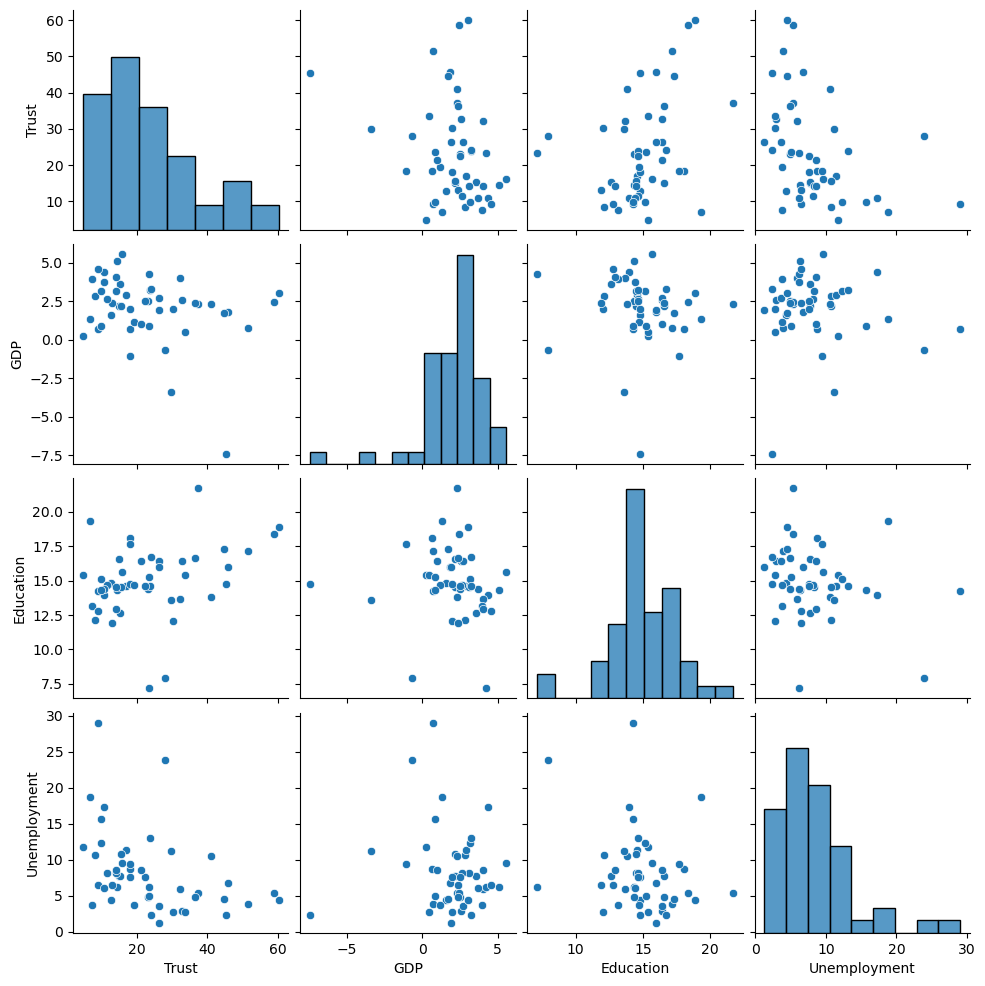

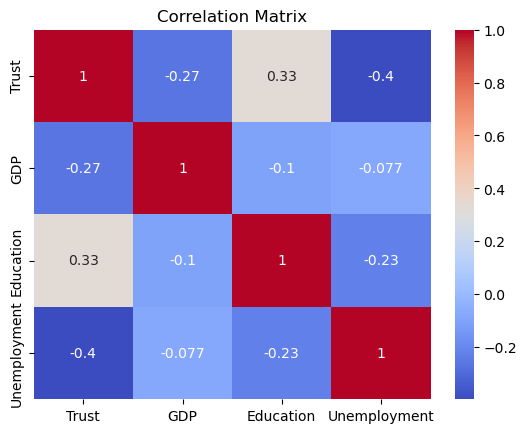

In [17]:
print(df.describe())

sns.pairplot(df)
plt.show()

corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

The dataset shows considerable variation across countries. Trust levels differ widely, indicating differences in societal confidence. GDP growth ranges from negative to strong positive values, reflecting diverse economic conditions. Education levels are relatively more consistent across countries, while unemployment rates vary moderately. Overall, the variation in these variables makes the dataset suitable for regression analysis.

### Regression Function


In [ ]:
def run_model(features):
    X = df[list(features)]
    X = sm.add_constant(X)
    y = df['Trust']
    model = sm.OLS(y, X).fit()
    return model

In [18]:
# Subset Models
features= ['GDP','Education','Unemployment']
results = []

for k in range(1, len(features)+1):
    for combo in itertools.combinations(features, k):
        model = run_model(combo)
        results.append({
            'Model': combo,
            'R2': model.rsquared,
            'Adj_R2': model.rsquared_adj,
            'AIC': model.aic,
            'BIC': model.bic
        })
        print("\nModel:", combo)
        print(model.summary())

results_df = pd.DataFrame(results)
print(results_df.sort_values(by='Adj_R2', ascending=False))


Model: ('GDP',)
                            OLS Regression Results                            
Dep. Variable:                  Trust   R-squared:                       0.071
Model:                            OLS   Adj. R-squared:                  0.051
Method:                 Least Squares   F-statistic:                     3.570
Date:                Sun, 05 Apr 2026   Prob (F-statistic):             0.0650
Time:                        13:20:37   Log-Likelihood:                -195.65
No. Observations:                  49   AIC:                             395.3
Df Residuals:                      47   BIC:                             399.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         26.7714      2.663   

### Summary

#### 1. Individual Models (Single Variable)

* **GDP only**

  * Very weak explanatory power (R² = 0.07)
  * Not statistically significant (p = 0.065)
  GDP alone is a **poor predictor of trust**

* **Education only**

  * Slight improvement (R² = 0.11)
  * Statistically significant (p = 0.021)
  Higher education is associated with **higher trust**

* **Unemployment only**

  * Strongest single predictor (R² = 0.158)
  * Highly significant (p = 0.005)
  Higher unemployment → **lower trust**



#### 2. Two-Variable Models

* **GDP + Education**

  * Education remains significant
  * GDP still weak
  Education drives the model here

* **GDP + Unemployment**

  * R² = 0.246 (strong improvement)
  * Both variables significant
  **Very strong model**
  * GDP: negative effect
  * Unemployment: negative effect

* **Education + Unemployment**

  * Unemployment significant
  * Education becomes weaker
  Unemployment dominates


### 3. Full Model (Best Overall) 

**GDP + Education + Unemployment**

* **R² = 0.291 (highest)**
* **Adjusted R² = 0.244 (best)**
* **Lowest AIC = 386 → best model**

### Key results:

* **Unemployment:** significant negative effect (p = 0.007)
* **GDP:** significant negative effect (p = 0.037)
* **Education:** marginal (p = 0.098)


### Key Insights

#### 1. Unemployment is the strongest predictor

* Consistently significant across models
* Higher unemployment → lower trust



#### 2. GDP becomes important only in combination

* Not significant alone
* Significant when combined with other variables
* Shows **negative relationship** (important to discuss)



#### 3. Education has a weaker role

* Significant alone
* Becomes less important when other variables are included
Suggests overlapping effects with other variables



### Final Model Choice

The **full model (GDP, Education, Unemployment)** is selected as the optimal model because it has the highest adjusted R² and lowest AIC, indicating the best balance between explanatory power and model complexity.



### Simple Explanation 

Trust in a country depends on multiple factors. The most important factor is unemployment—countries with higher unemployment tend to have lower trust. Economic growth and education also play a role, but their effects are weaker compared to unemployment.





### Full Model Diagnostics

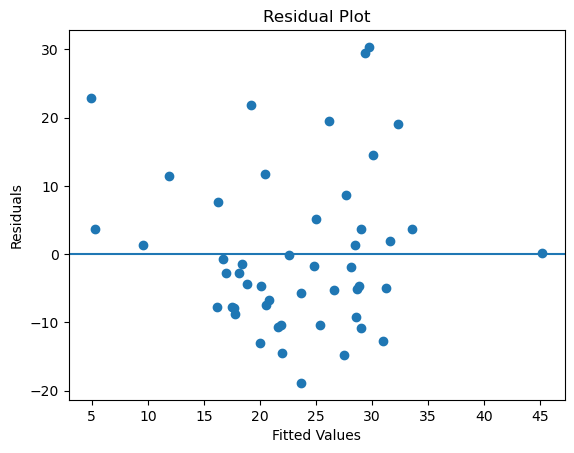

In [19]:
full_model = run_model(features)

# Residuals
residuals = full_model.resid
fitted = full_model.fittedvalues

plt.scatter(fitted, residuals)
plt.axhline(0)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

###  Leverage & Influence

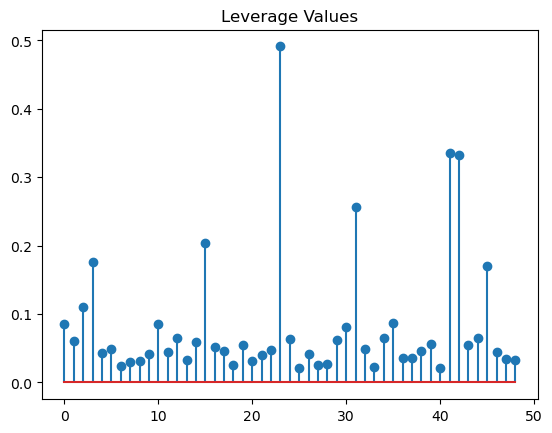

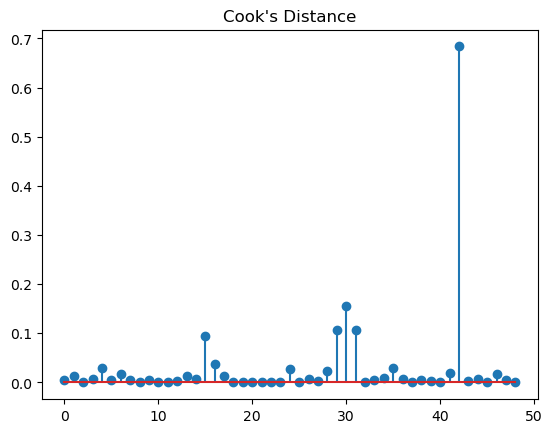

In [20]:
influence = full_model.get_influence()
leverage = influence.hat_matrix_diag
cooks = influence.cooks_distance[0]

plt.stem(leverage)
plt.title("Leverage Values")
plt.show()

plt.stem(cooks)
plt.title("Cook's Distance")
plt.show()

The leverage plot shows that most observations have low leverage, indicating typical predictor values. However, a few observations exhibit high leverage, meaning they have unusual combinations of GDP, education, and unemployment. These points have the potential to strongly influence the regression model and should be examined carefully


The Cook’s Distance plot indicates that most observations have little influence on the model. However, one observation shows a very large Cook’s Distance value which suggests it has a strong impact on the regression results. This observation likely corresponds to a country with extreme economic conditions, such as very high unemployment. Several other points show moderate influence and should also be considered.

### Identify influential points

In [21]:
threshold = 4/len(df)
influential_points = np.where(cooks > threshold)[0]
print("Influential Points Index:", influential_points)
print(df.iloc[influential_points])

Influential Points Index: [15 29 30 31 42]
        Country      Trust       GDP  Education  Unemployment
15       Greece   6.970984  1.316892  19.316195     18.756250
29  Netherlands  58.774817  2.412673  18.356880      5.337000
30  New Zealand  60.081722  3.045101  18.866933      4.431250
31     Pakistan  23.380464  4.236456   7.154948      6.171750
42        Sudan  27.872802 -0.653531   7.932330     23.836875


Several influential observations were identified using Cook’s Distance, including countries such as Greece, Netherlands, New Zealand, Pakistan, and Sudan. These observations exhibit extreme values in variables such as trust, education, and unemployment. However, since these are valid real-world data points and not errors, they were retained in the analysis to preserve the integrity and representativeness of the dataset.

### Final Model Selection

In [23]:
best_model = results_df.sort_values(by='Adj_R2', ascending=False).iloc[0]
print("Best Model Based on Adjusted R2:")
print(best_model)

Best Model Based on Adjusted R2:
Model     (GDP, Education, Unemployment)
R2                               0.29119
Adj_R2                          0.243936
AIC                           386.015884
BIC                           393.583165
Name: 6, dtype: object


The model including GDP, Education, and Unemployment was selected as the optimal model based on the highest adjusted R² and lowest AIC and BIC values. This indicates that the full model provides the best balance between explanatory power and model simplicity. Although not all variables are individually significant, their combined effect improves the model’s overall performance.

## Final Conclusion:   
This study examined the relationship between trust and three key factors: GDP, education, and unemployment across 48 countries in 2018. The results show that individual variables such as GDP and education alone do not significantly explain variations in trust. However, when combined in a multiple regression model, the explanatory power improves substantially.


Among all models tested, the full model (GDP, Education, and Unemployment) was identified as the optimal model based on the highest adjusted R² and lowest AIC. This indicates that trust is influenced by a combination of economic and social factors rather than any single variable.

The analysis reveals that unemployment has the most consistent negative relationship with trust, suggesting that higher unemployment levels are associated with lower public confidence. GDP also shows a statistically significant effect in the full model, although its negative relationship may reflect underlying complexities in the data. Education, while theoretically important, was not found to be a strong predictor in this dataset.

Diagnostic checks confirmed that the regression assumptions are reasonably satisfied, with no major issues of non-linearity or influential outliers. Therefore, all observations were retained in the analysis.